In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import torch
import numpy as np
sys.path.append(os.path.abspath('../scripts'))
from supporting.load_data import load_data, build_data_loaders, x_scale, y_scale, y_unscale
from sklearn import metrics
from torch import nn, optim
import torch.nn.functional as F

In [2]:
def get_device():
    ''' function to get the device the NN is running on, CPU or GPU
    '''
    if torch.cuda.is_available():
        device = torch.device("cuda:0")
    else: 
        device = torch.device("cpu")
        
    return device

In [3]:
config = {
    "model_type": "skip-mini",
    "input_shape": 4,
    "amplitude_shape": 36,
    "data_dir": "/scratch/hakula/dataset",
    "seed": 42,
    "var_y": [
        "y5",
        "y6"
    ],
    "use_MC_sample": False,
    "train-sample-size": 10000000,
    "validate-sample-size": 500000,
    "test-sample-size": 500000,
    "activation": "leaky_relu",
    "width": 30,
    "depth": 12,
    "skip_block_layers": 5,
    "lr_decay_type": "plateau",
    "initial_lr": 0.001,
    "lr_patience": 10,
    "lr_factor": 0.8,
    "lr_delta": 7e-05,
    "batch_size": 1024,
    "steps_per_epoch": 2400,
    "early_stopping_start_epoch": 150,
    "patience": 25,
    "loss": "huber",
    "base_directory": "../models/",
    "epochs": 2000,
    "model-uuid": "UUID",
    "train-samples-used": 6,
    "validate-samples-used": 6,
    "test-samples-used": 6,
    "n_targets": 2
}

In [ ]:
# df2, spark2 = load_data(config)

[]
['y5', 'y6']


In [4]:
torch.set_default_dtype(torch.float64)

In [5]:
class MyDataset(torch.utils.data.Dataset):
    '''Class to convert dataframe to torch tensor'''
    def __init__(self, x, y, config):
        x = x.copy(deep=True)
        y = y.copy(deep=True)

        # Vectorized scaling (if applicable)
        x['x1'] = x_scale(x['x1'])  # Or use apply if x_scale isn't vectorized

        # Number of targets
        config['n_targets'] = y.shape[1]

        for column in y.columns:
            y[column] = y[column].apply(y_scale)

        device = get_device()
        self.x = torch.tensor(x.values, dtype=torch.float64).to(device)
        self.y = torch.tensor(y.values, dtype=torch.float64).reshape(-1, config['n_targets']).to(device)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

df, spark = load_data(config)

x_cols = ['x1', 'x2', 'x3', 'x4']
y_cols = config["var_y"]
x_train = df["train"][x_cols]
y_train = df["train"][y_cols]
x_val = df["validate"][x_cols]
y_val = df["validate"][y_cols]
x_test = df["test"][x_cols]
y_test = df["test"][y_cols]

train_dataset = MyDataset(x_train, y_train, config)
val_dataset   = MyDataset(x_val, y_val, config)
test_dataset  = MyDataset(x_test, y_test, config)

# load the data into torch tensor batches
batch_size = config["batch_size"]
numworkers = 4 if get_device().type == 'cpu' else 0

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=numworkers, drop_last=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=True, num_workers=numworkers, drop_last=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=numworkers, drop_last=True)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/08/18 20:16:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/08/18 20:16:30 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


[]
['y5', 'y6']


In [6]:
model_path = "/home/hakula/qqzz4l-NN/models/skip-mini_a18ff108_30_12_5/a18ff108.best_weights.pt"

In [ ]:
def test_model(model, test_data, config):
    ''' function for testing the model
        arguments:
            model: the pytorch model to nbe trained
            test_data: the test data loader
            config: the configurations file
        returns:
            the absolute error
            the R2 score
    '''
    
    for i, data in enumerate(test_data):
        
        # forward prop
        x, y = data
        y_p = model(x)
        
        # store data
        if i == 0:
            x_test = x.cpu().detach().numpy()
            y_test = y.cpu().detach().numpy()
            y_pred = y_p.cpu().detach().numpy()
        else: 
            x_test = np.vstack((x_test, x.cpu().detach().numpy()))
            y_test = np.vstack((y_test, y.cpu().detach().numpy()))
            y_pred = np.vstack((y_pred, y_p.cpu().detach().numpy()))
        
    
    # accuracy
    y_test = np.array(y_test).reshape(-1, config['n_targets'])
    y_pred = np.array(y_pred).reshape(-1, config['n_targets'])
    abs_score = (1 - np.mean(np.abs((y_pred - y_test)/y_test)))*100
    r2_score = metrics.r2_score(y_test, y_pred)*100
    
    # save test results
    df_pred = pd.DataFrame(x_test, columns=['x'+str(i+1) for i in range(config['input_shape'])])
    
    # unscale the target
    scaled_cname = [s + '_scaled' for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame(y_test, columns=scaled_cname)], axis=1)
    for col in df_pred.columns[4:]:
        df_pred[col[:-7]] = df_pred[col].apply(lambda y: y_unscale(y))
    # y_test_real = pd.DataFrame(np.vectorize(y_unscale)(y_test), columns=config['var_y']) # 
    # df_pred = pd.concat([df_pred, y_test_real], axis=1)
    y_test_real = df_pred.iloc[:,-config['n_targets']:].to_numpy()
    
    # stuff in the scaled predictions
    pred_cname = [s + '_scaled_pred' for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame(y_pred, columns=pred_cname)], axis=1)
    
    # stuff in the unscaled predictions
    pred_cname = [s + '_pred' for s in config['var_y']]
    for col in df_pred.columns[-config['n_targets']:]:
        df_pred[col[:-12]+'_pred'] = df_pred[col].apply(lambda y: y_unscale(y))
    # y_pred_real = pd.DataFrame(np.vectorize(y_unscale)(y_pred), columns=pred_cname) # .apply(lambda y: y_unscale(y))
    # df_pred = pd.concat([df_pred, y_pred_real], axis=1)
    y_pred_real = df_pred.iloc[:,-config['n_targets']:].to_numpy()
    
    # calculate the deltas for the scaled and unscaled targets
    scaled_delta_cname = ['scaled_delta_' + s for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame((y_pred - y_test)/y_test*100, columns=scaled_delta_cname)], axis=1)
    delta_cname = ['delta_' + s for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame((y_pred_real - y_test_real)/y_test_real*100, columns=delta_cname)], axis=1)
    
    #same the whole dataframe
    #df_pred.to_csv(config['directory']+'/test-results-'+config['model-uuid']+'-'+f'{abs_score:.6f}-{r2_score:.6f}.csv')
    
    # # plot all the scaled and real deltas
    # for c in scaled_delta_cname:
    #     make_error_plot(config, df_pred, col=c)
    # for c in delta_cname:
    #     make_error_plot(config, df_pred, col=c)
        
    test_metrics = {}
    test_metrics['r2'] = {}
    test_metrics['abs_score'] = {}
    num_vars = len(config['var_y'])
    base_length = config['input_shape'] + num_vars
    for i in range(base_length, base_length + num_vars):
        test = df_pred.iloc[:,i].values
        pred = df_pred.iloc[:,i + 2 * num_vars].values
        test_metrics['r2'][config['var_y'][i - base_length]] = metrics.r2_score(test, pred)*100
        test_metrics['abs_score'][config['var_y'][i - base_length]] = 100 - np.abs(df_pred.iloc[:,i + 4 * num_vars]).mean()
    
    test_metrics['r2']['model'] = r2_score
    test_metrics['abs_score']['model'] = abs_score
    
    return test_metrics, df_pred


In [8]:
def get_activation(activation_str):
    if activation_str == 'leaky_relu':
        return nn.LeakyReLU()
    elif activation_str == 'relu':
        return nn.ReLU()
    if activation_str == 'softplus':
        return nn.Softplus()
    if activation_str == 'swish':
        return nn.SiLU()
    if activation_str == 'sigmoid':
        return nn.Sigmoid()
    if activation_str == 'tanh':
        return nn.Tanh()
    if activation_str == 'prelu':
        return nn.PReLU()
    if activation_str == 'elu':
        return nn.ELU()

# Residual module (equivalent to 'module' in Keras)
class ResidualBlock(nn.Module):
    def __init__(self, in_dim, width, n_skip_layers, activation='swish'):
        super().__init__()
        layers = []
        orig_in_dim = in_dim
        for _ in range(n_skip_layers - 1):
            layers.append(nn.Linear(in_dim, width))
            layers.append(get_activation(activation))
            in_dim = width
        layers.append(nn.Linear(width, orig_in_dim))  # projection back to input dim
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return x + self.net(x)

# Full model (equivalent to 'model' in Keras)
class SkipModel(nn.Module):
    def __init__(self, input_dim, width, depth, n_skip_layers, output_dim, activation='swish'):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, width),
            get_activation(activation)
        )
        self.res_blocks = nn.Sequential(*[
            ResidualBlock(in_dim=width, width=width, n_skip_layers=n_skip_layers, activation=activation) for _ in range(depth)
        ])
        self.output_layer = nn.Linear(width, output_dim)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.res_blocks(x)
        return self.output_layer(x)


In [9]:
width = config['width']
depth = config['depth']
n_skip_layers = config['skip_block_layers']
activation = config['activation']

model = SkipModel(config["input_shape"], width, depth, n_skip_layers, len(y_cols), activation)
model.to(device=get_device())

SkipModel(
  (input_layer): Sequential(
    (0): Linear(in_features=4, out_features=30, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
  )
  (res_blocks): Sequential(
    (0): ResidualBlock(
      (net): Sequential(
        (0): Linear(in_features=30, out_features=30, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Linear(in_features=30, out_features=30, bias=True)
        (3): LeakyReLU(negative_slope=0.01)
        (4): Linear(in_features=30, out_features=30, bias=True)
        (5): LeakyReLU(negative_slope=0.01)
        (6): Linear(in_features=30, out_features=30, bias=True)
        (7): LeakyReLU(negative_slope=0.01)
        (8): Linear(in_features=30, out_features=30, bias=True)
      )
    )
    (1): ResidualBlock(
      (net): Sequential(
        (0): Linear(in_features=30, out_features=30, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Linear(in_features=30, out_features=30, bias=True)
        (3): LeakyReLU(negative_slope=0.01)
     

In [10]:
best_weights_path = model_path
model.load_state_dict(torch.load(best_weights_path, map_location=torch.device('cuda' if torch.cuda.is_available() else 'cpu')))

/tmp/ipykernel_668424/3790447714.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_weights_path, map_location=torch.device('cuda' if 

<All keys matched successfully>

In [20]:
import os, json
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error, r2_score

# def _safe_mape(y, yhat):
#     mask = np.abs(y) > 1e-12
#     if mask.sum() == 0:
#         return np.nan
#     return mean_absolute_percentage_error(y[mask], yhat[mask])

def _percent_delta(y_true, y_pred):
    """(y_pred - y_true)/y_true * 100 with zero-guard → NaNs where denom≈0."""
    delta = np.full_like(y_true, np.nan, dtype=float)
    mask = np.abs(y_true) > 1e-12
    delta[mask] = (y_pred[mask] - y_true[mask]) / y_true[mask] * 100.0
    return delta

def _save_error_plots_from_arrays(delta_matrix, labels, out_path, cutoff=5):
    """Overlay histogram for each target column in delta_matrix."""
    plt.figure()
    for j, name in enumerate(labels):
        col = delta_matrix[:, j]
        m = np.isfinite(col)
        if cutoff is not None:
            m &= (np.abs(col) < cutoff)
        data = col[m]
        if data.size == 0:
            continue
        plt.hist(data, bins=100, histtype='step', label=name, density=True)
    plt.grid(True, linestyle='dotted', alpha=0.5)
    plt.xlabel(r'$\delta$')
    plt.ylabel('pdf')
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()

def evaluate_model(model, dataloader, device, output_dir, config):
    """
    Evaluate a trained model and save:
      - metrics.json (scaled & unscaled)
      - hist_unscaled_overlay.png, hist_scaled_overlay.png
    Requires a globally available scalar y_unscale(y: float) -> float.
    """
    os.makedirs(output_dir, exist_ok=True)

    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)
            pred = model(xb).cpu()
            all_preds.append(pred)
            all_targets.append(yb.cpu())

    y_true = torch.cat(all_targets, dim=0).numpy()
    y_pred = torch.cat(all_preds, dim=0).numpy()

    y_names = config["var_y"]
    assert y_true.ndim == 2 and y_true.shape[1] == len(y_names), \
        "Mismatch between targets array shape and config['var_y']"

    # -------- Scaled metrics --------
    scaled = {}
    overall_mape = mean_absolute_percentage_error(y_true, y_pred)
    overall_r2   = r2_score(y_true, y_pred)
    overall_abs  = (1 - overall_mape) * 100 if np.isfinite(overall_mape) else np.nan
    scaled["overall"] = {"MAPE": float(overall_mape), "R2": float(overall_r2), "abs_score": float(overall_abs)}
    scaled["per_target"] = {}
    for j, name in enumerate(y_names):
        mape_j = mean_absolute_percentage_error(y_true[:, j], y_pred[:, j])
        r2_j   = r2_score(y_true[:, j], y_pred[:, j])
        abs_j  = (1 - mape_j) * 100 if np.isfinite(mape_j) else np.nan
        scaled["per_target"][name] = {"MAPE": float(mape_j), "R2": float(r2_j), "abs_score": float(abs_j)}

    # -------- Unscaled metrics --------
    # Your y_unscale is scalar-only; vectorize it.
    y_unscale_vec = np.vectorize(y_unscale)
    y_true_un = y_unscale_vec(y_true)
    y_pred_un = y_unscale_vec(y_pred)

    unscaled = {}
    overall_mape_un = mean_absolute_percentage_error(y_true_un, y_pred_un)
    overall_r2_un   = r2_score(y_true_un, y_pred_un)
    overall_abs_un  = (1 - overall_mape_un) * 100 if np.isfinite(overall_mape_un) else np.nan
    unscaled["overall"] = {"MAPE": float(overall_mape_un), "R2": float(overall_r2_un), "abs_score": float(overall_abs_un)}
    unscaled["per_target"] = {}
    for j, name in enumerate(y_names):
        mape_j_un = mean_absolute_percentage_error(y_true_un[:, j], y_pred_un[:, j])
        r2_j_un   = r2_score(y_true_un[:, j], y_pred_un[:, j])
        abs_j_un  = (1 - mape_j_un) * 100 if np.isfinite(mape_j_un) else np.nan
        unscaled["per_target"][name] = {"MAPE": float(mape_j_un), "R2": float(r2_j_un), "abs_score": float(abs_j_un)}

    # -------- Deltas (arrays, no DataFrame) --------
    scaled_delta   = _percent_delta(y_true,    y_pred)
    unscaled_delta = _percent_delta(y_true_un, y_pred_un)

    # -------- Save metrics JSON --------
    metrics = {"scaled": scaled, "unscaled": unscaled, "meta": {"num_samples": int(y_true.shape[0]), "targets": y_names}}
    out_path = os.path.join(output_dir, "metrics.json")
    with open(out_path, "w") as f:
        json.dump(metrics, f, indent=2)

    # -------- Save plots (overlay style) --------
    _save_error_plots_from_arrays(
        unscaled_delta, y_names, os.path.join(output_dir, "hist_unscaled_overlay.png"), cutoff=5
    )
    _save_error_plots_from_arrays(
        scaled_delta, y_names, os.path.join(output_dir, "hist_scaled_overlay.png"), cutoff=5
    )

    # Console summary
    print("\n=== Evaluation (SCALED) ===")
    print(f"Overall MAPE      : {scaled['overall']['MAPE']:.6f}")
    print(f"Overall R2        : {scaled['overall']['R2']:.6f}")
    print(f"Overall abs_score : {scaled['overall']['abs_score']:.6f}")
    for n, v in scaled["per_target"].items():
        print(f"{n} - MAPE: {v['MAPE']:.6f} | R2: {v['R2']:.6f} | abs_score: {v['abs_score']:.6f}")

    print("\n=== Evaluation (UNSCALED) ===")
    print(f"Overall MAPE      : {unscaled['overall']['MAPE']:.6f}")
    print(f"Overall R2        : {unscaled['overall']['R2']:.6f}")
    print(f"Overall abs_score : {unscaled['overall']['abs_score']:.6f}")
    for n, v in unscaled["per_target"].items():
        print(f"{n} - MAPE: {v['MAPE']:.6f} | R2: {v['R2']:.6f} | abs_score: {v['abs_score']:.6f}")

    print(f"\nSaved metrics to: {out_path}")
    print("Saved histograms to:",
          os.path.join(output_dir, "hist_unscaled_overlay.png"), "and",
          os.path.join(output_dir, "hist_scaled_overlay.png"))

    # return metrics, {"scaled_delta": scaled_delta, "unscaled_delta": unscaled_delta}


In [21]:
evaluate_model(model, test_loader, device = get_device(), output_dir = './json_dir', config=config)


=== Evaluation (SCALED) ===
Overall MAPE      : 0.007104
Overall R2        : 0.999297
Overall abs_score : 99.289628
y5 - MAPE: 0.007366 | R2: 0.999073 | abs_score: 99.263383
y6 - MAPE: 0.006841 | R2: 0.999522 | abs_score: 99.315872

=== Evaluation (UNSCALED) ===
Overall MAPE      : 0.011596
Overall R2        : 0.693168
Overall abs_score : 98.840391
y5 - MAPE: 0.011843 | R2: 0.735206 | abs_score: 98.815744
y6 - MAPE: 0.011350 | R2: 0.651130 | abs_score: 98.865038

Saved metrics to: ./json_dir/metrics.json
Saved histograms to: ./json_dir/hist_unscaled_overlay.png and ./json_dir/hist_scaled_overlay.png


In [14]:
test_metrics, df_pred = test_model(model, test_loader, config)

In [15]:
test_metrics

{'r2': {'y5': 73.52059761068325,
  'y6': 65.11295003793356,
  'model': 99.9297257891863},
 'abs_score': {'y5': 98.81574443787352,
  'y6': 98.86503816909607,
  'model': 99.28962779988962}}

In [ ]:
test_metrics

{'r2': {'y5': 73.52059761068325,
  'y6': 65.11295003793356,
  'model': 99.9297257891863},
 'abs_score': {'y5': 98.81574443787352,
  'y6': 98.86503816909607,
  'model': 99.28962779988962}}

In [72]:
test_metrics, df_pred = test_model(model, test_loader, config)

In [73]:
test_metrics

{'r2': {'y5': 99.65237919748836,
  'y6': 99.96046822645387,
  'model': 99.98783859020904},
 'abs_score': {'y5': 97.53042185781955,
  'y6': 98.3981684089182,
  'model': 98.8265236252143}}

In [13]:
d5 = df_pred[["y5_scaled", "y5_scaled_pred", "y5", "y5_pred"]].copy()

In [14]:
actual = d5["y5"].to_numpy()
pred = d5["y5_pred"].to_numpy()

In [15]:
metrics.r2_score(actual, pred)

0.7352059761068325

In [16]:
d5

,y5_scaled,y5_scaled_pred,y5,y5_pred
0,-5.167388,-5.164296,-174.455943,-173.914296
1,5.032969,5.033529,152.387746,152.473722
2,4.168857,4.169404,63.641536,63.676865
3,5.413599,5.411355,223.437810,222.934899
4,5.148154,5.146998,171.113443,170.914612
...,...,...,...,...
499707,-4.115073,-4.119528,-60.256685,-60.530210
499708,-2.779589,-2.778696,-15.112394,-15.098015
499709,-2.043512,-2.043194,-6.717664,-6.715215
499710,-2.497521,-2.498999,-11.152331,-11.170311


In [17]:
d5.rename(columns={"y5": "yi", "y5_pred": "yp"}, inplace=True)

In [18]:
d5

,y5_scaled,y5_scaled_pred,yi,yp
0,-5.167388,-5.164296,-174.455943,-173.914296
1,5.032969,5.033529,152.387746,152.473722
2,4.168857,4.169404,63.641536,63.676865
3,5.413599,5.411355,223.437810,222.934899
4,5.148154,5.146998,171.113443,170.914612
...,...,...,...,...
499707,-4.115073,-4.119528,-60.256685,-60.530210
499708,-2.779589,-2.778696,-15.112394,-15.098015
499709,-2.043512,-2.043194,-6.717664,-6.715215
499710,-2.497521,-2.498999,-11.152331,-11.170311


In [19]:
d5["num"] = (d5["yi"] - d5["yp"])**2

In [20]:
d5["den"] = (d5["yi"] - d5["yi"].mean())**2

In [21]:
d5["yi"] - d5["yi"].mean()

0        -158.199844
1         168.643845
2          79.897635
3         239.693908
4         187.369542
             ...    
499707    -44.000587
499708      1.143705
499709      9.538435
499710      5.103768
499711      6.261918
Name: yi, Length: 499712, dtype: float64

In [22]:
d5

,y5_scaled,y5_scaled_pred,yi,yp,num,den
0,-5.167388,-5.164296,-174.455943,-173.914296,0.293382,25027.190795
1,5.032969,5.033529,152.387746,152.473722,0.007392,28440.746344
2,4.168857,4.169404,63.641536,63.676865,0.001248,6383.632038
3,5.413599,5.411355,223.437810,222.934899,0.252919,57453.169677
4,5.148154,5.146998,171.113443,170.914612,0.039534,35107.345092
...,...,...,...,...,...,...
499707,-4.115073,-4.119528,-60.256685,-60.530210,0.074816,1936.051614
499708,-2.779589,-2.778696,-15.112394,-15.098015,0.000207,1.308061
499709,-2.043512,-2.043194,-6.717664,-6.715215,0.000006,90.981740
499710,-2.497521,-2.498999,-11.152331,-11.170311,0.000323,26.048444


In [23]:
d5_sorted = d5.sort_values(by="num", ascending=True)
n = d5_sorted["yi"].size
exclude = 20
d5_sorted.head(n-exclude)

,y5_scaled,y5_scaled_pred,yi,yp,num,den
334176,-1.589504,-1.589504,-3.901316,-3.901316,8.238707e-14,1.526406e+02
470477,-1.662747,-1.662747,-4.273779,-4.273780,1.455263e-13,1.435760e+02
12242,-3.453229,-3.453229,-30.602258,-30.602258,3.910216e-13,2.058123e+02
67743,-2.400530,-2.400530,-10.029016,-10.029015,4.342846e-13,3.877656e+01
485151,-1.723270,-1.723270,-4.602821,-4.602822,8.792746e-13,1.357989e+02
...,...,...,...,...,...,...
30394,-10.084806,-9.865581,-23974.940386,-19255.056293,2.227731e+07,5.740186e+08
136654,-9.989179,-9.730736,-21788.407015,-16825.924055,2.462624e+07,4.740266e+08
452621,-8.547819,4.551242,-5154.495578,93.749987,2.754408e+07,2.640150e+07
38074,-9.990645,-9.677523,-21820.364531,-15953.926932,3.441509e+07,4.754191e+08


In [24]:
d5h = d5_sorted.head(n-exclude)
d5h["num"].sum()/d5h["den"].sum()

0.0168591873721704

In [25]:
rscore = 1 - (d5h["num"].sum()/d5h["den"].sum())
print(f"r2: {rscore}")

r2: 0.9831408126278296


In [26]:
d5["eratio"] = d5["num"] / d5["den"]

In [27]:
d5["num"].sum()

8078784511.631169

In [28]:
d5["den"].sum()

30509693507.62461

In [29]:
d5["num"].sum()/d5["den"].sum()

0.26479402389316753

In [30]:
d5.describe()

,y5_scaled,y5_scaled_pred,yi,yp,num,den,eratio
count,499712.000000,499712.000000,499712.000000,499712.000000,4.997120e+05,4.997120e+05,4.997120e+05
mean,-0.754574,-0.757645,-16.256098,-16.397839,1.616688e+04,6.105455e+04,1.032758e+01
std,3.558973,3.558919,247.092445,218.779606,4.061634e+06,4.720049e+06,4.992579e+03
min,-10.787503,-10.021551,-48411.017079,-22505.318093,8.238707e-14,6.276554e-11,5.779738e-17
25%,-3.252303,-3.254499,-24.849805,-24.906632,4.906126e-04,4.956374e+01,1.541383e-06
50%,-2.400150,-2.401654,-10.024829,-10.041425,5.354474e-03,4.589622e+02,1.112865e-05
75%,3.492573,3.491064,31.870417,31.820844,4.691510e-02,7.152280e+03,7.220805e-05
max,10.151488,8.626613,25628.215377,5577.153719,1.872321e+09,2.342053e+09,3.280910e+06


In [31]:
df["test"].describe()

,x1,x2,x3,x4,y5,y6
count,5.000000e+05,500000.000000,500000.000000,5.000000e+05,500000.000000,500000.000000
mean,1.322977e-01,0.499488,0.499608,4.991959e-01,-16.257655,-61.390114
std,2.209668e-01,0.288688,0.288804,2.883080e-01,247.024539,428.071210
min,6.066240e-10,0.000004,0.000001,1.887156e-09,-48411.017079,-116564.245685
25%,3.043801e-03,0.249499,0.249103,2.496172e-01,-24.841399,-112.547726
50%,2.286045e-02,0.499663,0.499903,4.984359e-01,-10.020227,-40.613543
75%,1.516317e-01,0.749442,0.749377,7.483472e-01,31.816197,-5.215332
max,9.999568e-01,0.999998,0.999999,9.999981e-01,25628.215377,2429.490484


In [35]:
df2["train"][["y5", "y6"]].describe()

,y5,y6
count,3.393726e+06,3.393726e+06
mean,-1.594521e+01,-6.050320e+01
std,2.720736e+02,3.778383e+02
min,-1.023240e+05,-1.803410e+05
25%,-2.469845e+01,-1.122887e+02
50%,-1.000349e+01,-4.050615e+01
75%,3.155229e+01,-5.193020e+00
max,1.748139e+05,3.591211e+03


In [203]:
df2["validate"][["y5", "y6"]].describe()

,y5,y6
count,500000.000000,500000.000000
mean,-16.466201,-61.305328
std,261.580776,340.064596
min,-37324.080961,-65677.581312
25%,-24.721899,-112.674712
50%,-9.997374,-40.845249
75%,32.050851,-5.276774
max,35789.250730,2609.425032


In [204]:
df2["test"][["y5", "y6"]].describe()

,y5,y6
count,500000.000000,500000.000000
mean,-16.257655,-61.390114
std,247.024539,428.071210
min,-48411.017079,-116564.245685
25%,-24.841399,-112.547726
50%,-10.020227,-40.613543
75%,31.816197,-5.215332
max,25628.215377,2429.490484


In [205]:
d5_sorted.sort_values(by="num", ascending=False).head(exclude)

,y5_scaled,y5_scaled_pred,yi,yp,num,den
83643,10.151488,-9.778100,25628.215377,-17642.107428,1.872321e+09,6.576389e+08
430041,-10.512374,7.176308,-36766.665664,1307.069726,1.449609e+09,1.350593e+09
447592,-10.787503,-9.650669,-48411.017079,-15531.176685,1.081084e+09,2.342053e+09
14806,9.203909,-9.880709,9934.892708,-19548.581191,8.692752e+08,9.902536e+07
498791,-9.940706,8.041059,-20757.388685,3104.901602,5.694089e+08,4.301946e+08
392064,-9.932113,6.421998,-20579.777816,614.231304,4.491860e+08,4.228584e+08
13680,9.712763,6.318482,16526.205943,553.730429,2.551200e+08,2.736531e+08
217665,-9.627402,-7.912933,-15173.959392,-2731.392453,1.548175e+08,2.297560e+08
149684,-9.326668,6.388386,-11232.634065,593.895385,1.398668e+08,1.258071e+08
51500,9.159135,-6.941890,9499.837087,-1033.723794,1.109559e+08,9.055603e+07


In [207]:
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(d5_sorted.sort_values(by="num", ascending=False).head(100))


,y5_scaled,y5_scaled_pred,yi,yp,num,den
83643,10.151488,-9.778100,25628.215377,-17642.107428,1.872321e+09,6.576389e+08
430041,-10.512374,7.176308,-36766.665664,1307.069726,1.449609e+09,1.350593e+09
447592,-10.787503,-9.650669,-48411.017079,-15531.176685,1.081084e+09,2.342053e+09
14806,9.203909,-9.880709,9934.892708,-19548.581191,8.692752e+08,9.902536e+07
498791,-9.940706,8.041059,-20757.388685,3104.901602,5.694089e+08,4.301946e+08
392064,-9.932113,6.421998,-20579.777816,614.231304,4.491860e+08,4.228584e+08
13680,9.712763,6.318482,16526.205943,553.730429,2.551200e+08,2.736531e+08
217665,-9.627402,-7.912933,-15173.959392,-2731.392453,1.548175e+08,2.297560e+08
149684,-9.326668,6.388386,-11232.634065,593.895385,1.398668e+08,1.258071e+08
51500,9.159135,-6.941890,9499.837087,-1033.723794,1.109559e+08,9.055603e+07


In [37]:
train_metrics, dt_pred = test_model(model, train_loader, config)

In [38]:
train_metrics

{'r2': {'y5': 52.8469116488557,
  'y6': 72.8359351799995,
  'model': 99.9273310121217},
 'abs_score': {'y5': 98.7622880861018,
  'y6': 98.16711315076942,
  'model': 99.01778356463112}}

In [39]:
dt_pred

,x1,x2,x3,x4,y5_scaled,y6_scaled,y5,y6,y5_scaled_pred,y6_scaled_pred,y5_pred,y6_pred,scaled_delta_y5,scaled_delta_y6,delta_y5,delta_y6
0,0.110721,0.900602,0.602381,0.010955,4.488079,-4.506940,87.950404,-89.644044,4.489580,-4.510086,88.084012,-89.929631,0.033443,0.069796,0.151913,0.318578
1,0.651551,0.876057,0.841546,0.954210,-2.961619,-3.990747,-18.329244,-53.095294,-2.964427,-3.991118,-18.383599,-53.115352,0.094818,0.009289,0.296550,0.037777
2,0.319721,0.503555,0.832934,0.753556,3.092604,-4.807354,21.034379,-121.407257,3.090327,-4.804524,20.984272,-121.061421,-0.073616,-0.058853,-0.238216,-0.284856
3,0.648820,0.336787,0.606475,0.288724,-3.367520,-2.701102,-28.006515,-13.896136,-3.368099,-2.701797,-28.023293,-13.906489,0.017172,0.025723,0.059908,0.074506
4,0.386669,0.310212,0.955321,0.188839,-2.553050,-3.968063,-11.846231,-51.881991,-2.567462,-3.969920,-12.032699,-51.980279,0.564464,0.046796,1.574072,0.189445
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3393531,0.417274,0.078755,0.429089,0.148683,-4.292776,-4.741193,-72.169300,-113.570753,-4.303589,-4.750431,-72.964805,-114.634169,0.251898,0.194865,1.102276,0.936347
3393532,0.662590,0.818265,0.583783,0.372452,-2.853182,-3.204334,-16.342885,-23.639080,-2.854668,-3.204332,-16.368673,-23.639036,0.052078,-0.000056,0.157797,-0.000187
3393533,0.015902,0.608893,0.807121,0.378981,5.041903,-5.106344,153.764209,-164.065791,5.040890,-5.106539,153.607494,-164.097973,-0.020094,0.003818,-0.101919,0.019615
3393534,0.101784,0.690303,0.403743,0.012572,4.695953,-5.051788,108.503141,-155.301638,4.693770,-5.045537,108.264374,-154.327647,-0.046484,-0.123738,-0.220056,-0.627161


In [42]:
df_pred

,x1,x2,x3,x4,y5_scaled,y6_scaled,y5,y6,y5_scaled_pred,y6_scaled_pred,y5_pred,y6_pred,scaled_delta_y5,scaled_delta_y6,delta_y5,delta_y6
0,0.000131,0.147431,0.774351,0.245984,-5.167388,5.236248,-174.455943,186.963621,-5.164296,5.235466,-173.914296,186.816524,-0.059834,-0.014951,-0.310478,-0.078677
1,0.000542,0.705441,0.511854,0.034134,5.032969,-5.069397,152.387746,-158.078358,5.033529,-5.070821,152.473722,-158.305015,0.011134,0.028086,0.056419,0.143383
2,0.000753,0.348233,0.460954,0.283262,4.168857,-4.184300,63.641536,-64.647520,4.169404,-4.187727,63.676865,-64.872904,0.013106,0.081910,0.055512,0.348635
3,0.000866,0.659904,0.123490,0.852356,5.413599,-5.481205,223.437810,-239.135900,5.411355,-5.478758,222.934899,-238.549070,-0.041438,-0.044639,-0.225079,-0.245396
4,0.000906,0.547915,0.649524,0.693039,5.148154,-5.184982,171.113443,-177.570199,5.146998,-5.185651,170.914612,-177.689816,-0.022453,0.012915,-0.116199,0.067363
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499707,0.858574,0.084713,0.169534,0.451104,-4.115073,0.524211,-60.256685,0.689126,-4.119528,0.535246,-60.530210,0.707868,0.108267,2.105025,0.453933,2.719727
499708,0.858653,0.315792,0.713225,0.709775,-2.779589,-1.419106,-15.112394,-3.133422,-2.778696,-1.419514,-15.098015,-3.135109,-0.032120,0.028754,-0.095145,0.053838
499709,0.858838,0.609794,0.212700,0.336352,-2.043512,-1.287358,-6.717664,-2.623202,-2.043194,-1.285214,-6.715215,-2.615443,-0.015527,-0.166513,-0.036447,-0.295763
499710,0.858842,0.432198,0.130247,0.729713,-2.497521,-1.491892,-11.152331,-3.445499,-2.498999,-1.491721,-11.170311,-3.444739,0.059197,-0.011461,0.161222,-0.022059


In [44]:
# Get feature vector of offender (x1..x4 here)
offender_x = df_pred.loc[83643, ['x1','x2','x3','x4']].values


In [56]:
df_pred.iloc[[83643]]

,x1,x2,x3,x4,y5_scaled,y6_scaled,y5,y6,y5_scaled_pred,y6_scaled_pred,y5_pred,y6_pred,scaled_delta_y5,scaled_delta_y6,delta_y5,delta_y6
83643,0.936732,0.000014,0.601388,0.672658,10.151488,-11.603648,25628.215377,-109495.566621,-9.7781,-10.125433,-17642.107428,-24969.067139,-196.321842,-12.739229,-168.838611,-77.196276


In [51]:
# Training feature matrix
X_train = dt_pred[['x1','x2','x3','x4']].to_numpy()

# Euclidean distance
dist = np.linalg.norm(X_train - offender_x, axis=1)
closest_idx = np.argsort(dist)[:10]  # top 5 closest

closest_examples = dt_pred.iloc[closest_idx]

closest_examples

,x1,x2,x3,x4,y5_scaled,y6_scaled,y5,y6,y5_scaled_pred,y6_scaled_pred,y5_pred,y6_pred,scaled_delta_y5,scaled_delta_y6,delta_y5,delta_y6
595978,0.944029,0.004364,0.598551,0.679306,-7.099065,-4.785071,-1209.834805,-118.709890,-7.122559,-4.804464,-1238.618527,-121.054011,0.330940,0.405269,2.379145,1.974664
2567274,0.949912,0.017005,0.588054,0.685802,-5.599887,2.488185,-269.395716,11.039401,-5.613789,2.483474,-273.181130,10.982819,0.248263,-0.189325,1.405150,-0.512540
3317538,0.929211,0.018623,0.592180,0.653900,-5.589808,2.120096,-266.684329,7.331936,-5.590216,2.128259,-266.793474,7.400227,0.007293,0.385022,0.040927,0.931413
3095293,0.925879,0.008450,0.605426,0.698398,-6.496496,-3.564557,-661.814958,-34.323816,-6.490934,-3.519965,-658.138689,-32.783229,-0.085614,-1.251008,-0.555483,-4.488389
2393618,0.920598,0.004371,0.618325,0.652578,-7.193539,-5.193514,-1329.804655,-179.100254,-7.206118,-5.195844,-1346.650495,-179.520411,0.174864,0.044867,1.266791,0.234593
1786680,0.941661,0.012255,0.579793,0.653749,-5.988642,1.674969,-397.872555,4.338629,-6.011136,1.690394,-406.946516,4.421617,0.375613,0.920919,2.280620,1.912755
503113,0.911142,0.011719,0.607658,0.659559,-6.195631,-2.872811,-489.600883,-16.686668,-6.189356,-2.840993,-486.532145,-16.132778,-0.101276,-1.107545,-0.626784,-3.319358
138356,0.934951,0.010267,0.576330,0.690116,-6.236451,-2.327536,-510.041530,-9.252650,-6.244702,-2.328628,-514.275495,-9.263845,0.132300,0.046888,0.830122,0.120995
3230206,0.910365,0.017421,0.589572,0.669809,-5.770112,-0.514933,-319.573720,-0.673526,-5.785446,-0.462048,-324.527086,-0.587322,0.265738,-10.270170,1.549992,-12.798914
3334333,0.958353,0.019526,0.619277,0.667571,-5.389443,2.650295,-218.081268,13.158220,-5.412507,2.649316,-223.192828,13.144365,0.427944,-0.036942,2.343879,-0.105296


In [58]:
# Training feature matrix
X_test = df_pred[['x1','x2','x3','x4']].to_numpy()

# Euclidean distance
dist = np.linalg.norm(X_test - offender_x, axis=1)
closest_idx = np.argsort(dist)[:10]  # top 5 closest

closest_examples = df_pred.iloc[closest_idx]

closest_examples

,x1,x2,x3,x4,y5_scaled,y6_scaled,y5,y6,y5_scaled_pred,y6_scaled_pred,y5_pred,y6_pred,scaled_delta_y5,scaled_delta_y6,delta_y5,delta_y6
83643,0.936732,0.000014,0.601388,0.672658,10.151488,-11.603648,25628.215377,-109495.566621,-9.778100,-10.125433,-17642.107428,-24969.067139,-196.321842,-12.739229,-168.838611,-77.196276
469963,0.923598,0.014145,0.608934,0.691942,-5.944302,-1.040872,-380.573024,-1.831686,-5.966559,-0.998533,-389.160682,-1.714296,0.374416,-4.067698,2.256507,-6.408829
439764,0.918727,0.000620,0.598163,0.694727,-9.021213,-8.538031,-8275.813888,-5104.282698,-9.079499,-8.563586,-8772.570887,-5236.429606,0.646097,0.299308,6.002515,2.588942
30175,0.935281,0.013100,0.582869,0.692560,-5.969377,0.874631,-390.261743,1.397991,-5.985754,0.906456,-396.722349,1.475535,0.274357,3.638685,1.655455,5.546789
228134,0.945822,0.004354,0.594287,0.639502,-7.072598,-4.656821,-1178.208088,-104.300773,-7.097031,-4.669614,-1207.373801,-105.656554,0.345451,0.274718,2.475430,1.299877
356658,0.914005,0.022090,0.589360,0.683859,-5.494738,1.644463,-242.407632,4.178230,-5.522197,1.625511,-249.184212,4.081013,0.499750,-1.152515,2.795531,-2.326756
296098,0.908976,0.024396,0.589071,0.665272,-5.399347,1.670963,-220.261947,4.317288,-5.413276,1.670100,-223.365460,4.312697,0.257975,-0.051685,1.409010,-0.106322
175204,0.971748,0.014296,0.609487,0.687456,-5.677435,2.791589,-291.198962,15.306918,-5.694859,2.787669,-296.334849,15.243109,0.306899,-0.140446,1.763703,-0.416863
75974,0.933533,0.004628,0.614638,0.714529,-7.104468,-4.945977,-1216.394653,-139.608117,-7.119947,-4.966613,-1235.384755,-142.539903,0.217871,0.417235,1.561179,2.100011
60999,0.968718,0.027110,0.581053,0.679807,-4.968808,2.572296,-142.855310,12.095860,-4.986835,2.582371,-145.472171,12.228463,0.362812,0.391661,1.831826,1.096270


In [67]:
c5 = closest_examples[["x1", "x2", "x3", "x4", "y5_scaled", "y5_scaled_pred", "y5", "y5_pred"]].copy()
c5["sq_error_scaled"] = (c5["y5_scaled"] - c5["y5_scaled_pred"])**2
c5["sq_error_unscaled"] = (c5["y5"] - c5["y5_pred"])**2
c5

,x1,x2,x3,x4,y5_scaled,y5_scaled_pred,y5,y5_pred,sq_error_scaled,sq_error_unscaled
83643,0.936732,0.000014,0.601388,0.672658,10.151488,-9.778100,25628.215377,-17642.107428,397.188505,1.872321e+09
469963,0.923598,0.014145,0.608934,0.691942,-5.944302,-5.966559,-380.573024,-389.160682,0.000495,7.374787e+01
439764,0.918727,0.000620,0.598163,0.694727,-9.021213,-9.079499,-8275.813888,-8772.570887,0.003397,2.467675e+05
30175,0.935281,0.013100,0.582869,0.692560,-5.969377,-5.985754,-390.261743,-396.722349,0.000268,4.173943e+01
228134,0.945822,0.004354,0.594287,0.639502,-7.072598,-7.097031,-1178.208088,-1207.373801,0.000597,8.506388e+02
356658,0.914005,0.022090,0.589360,0.683859,-5.494738,-5.522197,-242.407632,-249.184212,0.000754,4.592204e+01
296098,0.908976,0.024396,0.589071,0.665272,-5.399347,-5.413276,-220.261947,-223.365460,0.000194,9.631795e+00
175204,0.971748,0.014296,0.609487,0.687456,-5.677435,-5.694859,-291.198962,-296.334849,0.000304,2.637733e+01
75974,0.933533,0.004628,0.614638,0.714529,-7.104468,-7.119947,-1216.394653,-1235.384755,0.000240,3.606240e+02
60999,0.968718,0.027110,0.581053,0.679807,-4.968808,-4.986835,-142.855310,-145.472171,0.000325,6.847959e+00


In [68]:
c6 = closest_examples[["x1", "x2", "x3", "x4", "y6_scaled", "y6_scaled_pred", "y6", "y6_pred"]].copy()
c6["sq_error_scaled"] = (c6["y6_scaled"] - c6["y6_scaled_pred"])**2
c6["sq_error_unscaled"] = (c6["y6"] - c6["y6_pred"])**2
c6

,x1,x2,x3,x4,y6_scaled,y6_scaled_pred,y6,y6_pred,sq_error_scaled,sq_error_unscaled
83643,0.936732,0.000014,0.601388,0.672658,-11.603648,-10.125433,-109495.566621,-24969.067139,2.185121e+00,7.144729e+09
469963,0.923598,0.014145,0.608934,0.691942,-1.040872,-0.998533,-1.831686,-1.714296,1.792636e-03,1.378032e-02
439764,0.918727,0.000620,0.598163,0.694727,-8.538031,-8.563586,-5104.282698,-5236.429606,6.530589e-04,1.746281e+04
30175,0.935281,0.013100,0.582869,0.692560,0.874631,0.906456,1.397991,1.475535,1.012836e-03,6.013014e-03
228134,0.945822,0.004354,0.594287,0.639502,-4.656821,-4.669614,-104.300773,-105.656554,1.636646e-04,1.838145e+00
356658,0.914005,0.022090,0.589360,0.683859,1.644463,1.625511,4.178230,4.081013,3.592044e-04,9.451187e-03
296098,0.908976,0.024396,0.589071,0.665272,1.670963,1.670100,4.317288,4.312697,7.458752e-07,2.107033e-05
175204,0.971748,0.014296,0.609487,0.687456,2.791589,2.787669,15.306918,15.243109,1.537165e-05,4.071572e-03
75974,0.933533,0.004628,0.614638,0.714529,-4.945977,-4.966613,-139.608117,-142.539903,4.258591e-04,8.595367e+00
60999,0.968718,0.027110,0.581053,0.679807,2.572296,2.582371,12.095860,12.228463,1.014990e-04,1.758364e-02


# Eval code

# Error plots 

## h2 real and imaginary

In [74]:
# df_h2 = pd.read_csv('../models/skip-light-torch-4D-y5_y6-fe15fc3c--13-29-leaky_relu-1024-adam-exp-schedule-mse-val_mse-96.667286-99.840031/test-results-fe15fc3c-96.667286-99.840031.csv')
df_h2 = df_pred

In [23]:
df_h2

,x1,x2,x3,x4,y5_scaled,y6_scaled,y5,y6,y5_scaled_pred,y6_scaled_pred,y5_pred,y6_pred,scaled_delta_y5,scaled_delta_y6,delta_y5,delta_y6
0,0.001656,0.771066,0.436337,0.521262,5.032712,-5.070183,152.348295,-158.203404,5.037163,-5.077358,153.032397,-159.349856,0.088445,0.141521,0.449038,0.724670
1,0.002124,0.581542,0.511984,0.521890,5.164520,-5.203726,173.953388,-180.948847,5.163800,-5.204524,173.827608,-181.094216,-0.013926,0.015347,-0.072307,0.080337
2,0.002743,0.463915,0.528051,0.508386,4.962266,-5.001355,141.917239,-147.614354,4.960350,-4.998779,141.643742,-147.232091,-0.038601,-0.051496,-0.192716,-0.258960
3,0.003052,0.961049,0.543344,0.505631,3.579522,-3.607909,34.856411,-35.888819,3.580510,-3.612176,34.891835,-36.046573,0.027586,0.118277,0.101628,0.439562
4,0.003572,0.361104,0.520037,0.524839,4.504727,-4.542012,89.443672,-92.879537,4.505312,-4.547334,89.496578,-93.380452,0.012982,0.117162,0.059151,0.539316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499707,0.502007,0.167341,0.524737,0.520739,-4.328688,-4.410747,-74.844741,-81.330981,-4.324564,-4.405729,-74.532576,-80.918821,-0.095279,-0.113784,-0.417084,-0.506769
499708,0.502228,0.420521,0.513963,0.519415,-3.474266,-3.918505,-31.274130,-49.325172,-3.474761,-3.921061,-31.290113,-49.453942,0.014250,0.065216,0.051105,0.261062
499709,0.502403,0.555022,0.528000,0.677927,-3.237579,-4.065832,-24.471969,-57.313389,-3.239206,-4.067871,-24.513451,-57.432402,0.050259,0.050146,0.169505,0.207653
499710,0.502513,0.233200,0.525068,0.503832,-4.021274,-4.145710,-54.772100,-62.162472,-4.023046,-4.141329,-54.871030,-61.886361,0.044072,-0.105676,0.180621,-0.444176


In [25]:
100 - df_h2["delta_y6"].abs().mean()

98.46328103714157

In [19]:
df = df_h2
df[["y18", "y18_pred"]]

,y18,y18_pred
0,-240.569423,-240.051323
1,182.917455,183.183028
2,-133.756088,-134.064574
3,152.983583,152.784979
4,43.834251,43.772769
...,...,...
499707,-0.575642,-0.567680
499708,-0.049279,-0.047631
499709,0.004035,0.005220
499710,-0.003356,-0.003423


In [20]:
(df["y18"] - df["y18_pred"]).abs().mean()

0.26253495256637815

In [21]:
df18 = df[['y18', 'y18_pred']].copy()

# compute the raw difference (residual)
df18['diff'] = df18['y18'] - df18['y18_pred']

# compute percent‐error delta
df18['delta_y18'] = df18['diff'] / df18['y18'] * 100

# show the first few rows
df18

,y18,y18_pred,diff,delta_y18
0,-240.569423,-240.051323,-0.518100,0.215364
1,182.917455,183.183028,-0.265573,-0.145187
2,-133.756088,-134.064574,0.308486,-0.230633
3,152.983583,152.784979,0.198604,0.129820
4,43.834251,43.772769,0.061482,0.140260
...,...,...,...,...
499707,-0.575642,-0.567680,-0.007962,1.383179
499708,-0.049279,-0.047631,-0.001648,3.345074
499709,0.004035,0.005220,-0.001186,-29.388779
499710,-0.003356,-0.003423,0.000066,-1.978665


In [22]:
df18

,y18,y18_pred,diff,delta_y18
0,-240.569423,-240.051323,-0.518100,0.215364
1,182.917455,183.183028,-0.265573,-0.145187
2,-133.756088,-134.064574,0.308486,-0.230633
3,152.983583,152.784979,0.198604,0.129820
4,43.834251,43.772769,0.061482,0.140260
...,...,...,...,...
499707,-0.575642,-0.567680,-0.007962,1.383179
499708,-0.049279,-0.047631,-0.001648,3.345074
499709,0.004035,0.005220,-0.001186,-29.388779
499710,-0.003356,-0.003423,0.000066,-1.978665


In [23]:
pd.set_option('display.float_format', '{:.20f}'.format)
print(df18.sort_values('delta_y18', ascending=False)[0:10000])
#pd.reset_option('display.float_format')

                           y18                y18_pred  \
394627 -0.00000001415130412852  0.00023894021163783918   
83872  -0.00000005830274574237  0.00065944417556695889   
235088 -0.00000016518712797620  0.00067780894645830259   
447066  0.00000012136282379061 -0.00025519584472122325   
469834 -0.00000030725730404413  0.00048364667162603681   
...                        ...                     ...   
188542 -0.01956421279220776910 -0.01459324788284233065   
470137 -0.00106687172047337242 -0.00079585860744790793   
129780 -0.00178780378193366118 -0.00133390527583543417   
166947 -0.00348851273939487783 -0.00260301981407939920   
68612  -0.00399289840629535320 -0.00297943990445093121   

                          diff                    delta_y18  
394627 -0.00023895436294196770 1688567.78691105055622756481  
83872  -0.00065950247831270126 1131168.81531955185346305370  
235088 -0.00067797413358627878  410427.94429114111699163914  
447066  0.00025531720754501386  210375.1376002331671770

In [24]:
df18['abs_delta_y18'] = df18['delta_y18'].abs()
df18.reindex(df18['abs_delta_y18'].sort_values(ascending=False).index)[:20]

,y18,y18_pred,diff,delta_y18,abs_delta_y18
394627,-0.00000001415130412852,0.00023894021163783918,-0.00023895436294196770,1688567.78691105055622756481,1688567.78691105055622756481
174349,0.00000004445999479685,0.00066421033443209154,-0.00066416587443729469,-1493850.54467957490123808384,1493850.54467957490123808384
83872,-0.00000005830274574237,0.00065944417556695889,-0.00065950247831270126,1131168.81531955185346305370,1131168.81531955185346305370
454745,0.00000014133795644966,0.00102782720519556392,-0.00102768586723911426,-727112.44244226522278040648,727112.44244226522278040648
129262,0.00000014186663577220,0.00083006432833476751,-0.00082992246169899531,-585001.86261666985228657722,585001.86261666985228657722
265458,0.00000029966616921229,0.00146632703640592332,-0.00146602737023671104,-489220.17927160806721076369,489220.17927160806721076369
167526,0.00000017351899472828,0.00075735430414192173,-0.00075718078514719345,-436367.66472332144621759653,436367.66472332144621759653
235088,-0.00000016518712797620,0.00067780894645830259,-0.00067797413358627878,410427.94429114111699163914,410427.94429114111699163914
447066,0.00000012136282379061,-0.00025519584472122325,0.00025531720754501386,210375.13760023316717706621,210375.13760023316717706621
68210,0.00000030904595327286,0.00063966365080325716,-0.00063935460484998430,-206880.10895437828730791807,206880.10895437828730791807


In [25]:
df18.describe()

,y18,y18_pred,diff,delta_y18,abs_delta_y18
count,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000
mean,-0.09873022270206330275,-0.12681226991611474486,0.02808204721405149762,-2.48800281267444178823,33.63663255878972790924
std,116.53897857208340838042,116.32263826186792243789,6.31436787665629228883,4040.77896757665257609915,4040.63973024893175534089
min,-2711.30996042442302496056,-893.50647732938114131684,-2929.19046607193013187498,-1493850.54467957490123808384,0.00000000503477923354
25%,-17.18636083145364068514,-17.16490856342559112591,-0.02268088213931152008,-0.17248087157636082800,0.12681836325446588232
50%,-0.00001801405742440920,0.00035708719580906934,-0.00073072149663822028,0.09370807789880036820,0.29636656751019224698
75%,17.36856412752658940235,17.38148566056654686918,0.03772969782054147458,0.41619209980885235600,0.72006481672151223528
max,1164.17193049737852561520,802.89582431011319840763,1320.64006771039953491709,1688567.78691105055622756481,1688567.78691105055622756481


In [26]:
df18.abs()[20000:]["delta_y18"].abs().mean()

34.61662380223456

In [27]:
df18["y18"]

0        -240.56942296808205128400
1         182.91745493979775005755
2        -133.75608777624688627839
3         152.98358268819541194716
4          43.83425116481588901252
                    ...           
499707     -0.57564244598592373414
499708     -0.04927932203213103435
499709      0.00403454508865053185
499710     -0.00335636972818065260
499711      0.48196748411372070109
Name: y18, Length: 499712, dtype: float64

In [28]:
(df18["y18"] > 1e-3).sum()

241238

In [29]:
100 - df18["delta_y18"][df18["y18"] > 1e-3].abs().mean()

98.23394397531456

In [30]:
100 - df18["delta_y18"].abs().sort_values(ascending=False)[10:-1].mean()

81.12940249787744

In [31]:
df17 = df[['y17', 'y17_pred']].copy()

# compute the raw difference (residual)
df17['diff'] = df17['y17'] - df17['y17_pred']

# compute percent‐error delta
df17['delta_y17'] = df17['diff'] / df17['y17'] * 100

# show the first few rows
df17

,y17,y17_pred,diff,delta_y17
0,230.24095327649700948314,229.68272031454282000595,0.55823296195418947718,0.24245598101038348671
1,-174.14936483868277150577,-174.27503000777610964178,0.12566516909333813601,-0.07215941855989178866
2,128.71566947862038432504,129.34622629493898671171,-0.63055681631860238667,-0.48988349194216607163
3,-144.44316263615843354273,-144.83107975901265263019,0.38791712285421908746,-0.26856039135016274155
4,-42.23305095611935655597,-42.26762298604469947350,0.03457202992534291752,-0.08186012883905467719
...,...,...,...,...
499707,-1.59364159203566480016,-1.58430377807099098675,-0.00933781396467381342,0.58594190885454988660
499708,-0.49541102241317958033,-0.49480168655596390437,-0.00060933585721567596,0.12299602343273693950
499709,0.14287281616268288076,0.14178039852630486273,0.00109241763637801803,0.76460845787076170410
499710,-0.10359255108209897145,-0.10366034706768956219,0.00006779598559059075,-0.06544484606510095337


In [32]:
df17.reindex(df17['delta_y17'].abs().sort_values(ascending=False).index)[:10]

,y17,y17_pred,diff,delta_y17
24584,-0.00003467135703072444,0.00498535539257560778,-0.00502002674960633222,14478.88741463962651323527
374901,0.00120695153156180623,-0.14424186179170872535,0.14544881332327053158,12050.92412742195665487088
283910,0.00031364714112225300,-0.02748094384654620193,0.02779459098766845493,8861.73898739115611533634
203807,-0.00003595212308837858,0.00302135446686380149,-0.00305730658995218008,8503.82766669055308739189
280351,-0.00001119364520008048,0.00085935874779519139,-0.00087055239299527187,7777.20195195228006923571
313858,0.00026781025096944688,-0.01874417227389302276,0.01901198252486246965,7099.04959053693983150879
316548,0.00009155293802631803,0.00642897738031655841,-0.00633742444229024038,-6922.14207311235441011377
150347,-0.00013212699465903199,0.00700159285179657864,-0.00713371984645561064,5399.13880949532449449180
293467,-0.01514703784720450308,0.71232083775749877042,-0.72746787560470327350,4802.70718897664119140245
285650,0.00048336262862491708,0.01987897839856977988,-0.01939561576994486281,-4012.64281128270704357419


In [33]:
df_h2["delta_y17"]

0        -0.24245598101038348671
1         0.07215941855989178866
2         0.48988349194216607163
3         0.26856039135016274155
4         0.08186012883905467719
                   ...          
499707   -0.58594190885454988660
499708   -0.12299602343273693950
499709   -0.76460845787076170410
499710    0.06544484606510095337
499711   -0.04508626402890548307
Name: delta_y17, Length: 499712, dtype: float64

In [34]:
df_h2.describe()

,x1,x2,x3,x4,y17_scaled,y18_scaled,y17,y18,y17_scaled_pred,y18_scaled_pred,y17_pred,y18_pred,scaled_delta_y17,scaled_delta_y18,delta_y17,delta_y18
count,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000
mean,0.49925700527143107577,0.49946930487487523065,0.49959831168449431171,0.49919920875870060772,-0.00063862245736353337,-0.00028417318975051205,0.20054609594388358995,-0.09873022270206330275,0.00010149867027560273,0.00005157751596282557,0.23204444376973026865,-0.12681226991611474486,-0.12163726002215985433,2.49118691170428352422,-0.09468110657727639434,2.48800281267444178823
std,0.28840179849242147947,0.28869124178696292660,0.28880734299482851979,0.28830808721535133854,2.97146818682792446253,3.45657781126697116747,97.36793468266688478252,116.53897857208340838042,2.97149687051068145394,3.45625517262585368883,94.84314354035171845680,116.32263826186792243789,42.19201708298916742024,4039.63342845237457368057,43.44526057607399849303,4040.77896757665257609915
min,0.00000014615929290980,0.00000367488420800000,0.00000149422516200000,0.00000000188715600000,-8.85950544622724400767,-7.90555593472132756006,-7039.99973038681309844833,-2711.30996042442302496056,-7.56832198674903899871,-6.79627214420749847790,-1934.88910699069856491406,-893.50647732938114131684,-14443.41280927420484658796,-1688366.10955853876657783985,-14478.88741463962651323527,-1688567.78691105055622756481
25%,0.24945223390406567887,0.24947608692559200549,0.24909028326087523375,0.24961780091905599877,-2.25544151368222989262,-2.90067190827180088064,-8.53950420214541061625,-17.18636083145364068514,-2.25416087069196358073,-2.89949163199179693606,-8.52729532227355946361,-17.16490856342559112591,-0.12329655026149441421,-0.15399419605298492186,-0.32061424542041772057,-0.41619209980885235600
50%,0.49907971771260983829,0.49964960652232598415,0.49989675755400297952,0.49843940292516353274,-0.00236280034877890156,-0.00001801389517317410,-0.00236559396370505937,-0.00001801405742440920,-0.00173923365152527359,0.00035702345533277467,-0.00174074699927062593,0.00035708719580906934,-0.00436364718585258854,-0.02392907118006050438,-0.01293069133711112484,-0.09370807789880036820
75%,0.74849174774416449285,0.74942372292592418503,0.74936844710294003846,0.74833402423672923387,2.25359217770292552530,2.91064073139427925696,8.52187875687064888552,17.36856412752658940235,2.25450433038581010692,2.91134394307412947001,8.53056812764425309581,17.38148566056654686918,0.09031609678747315462,0.04609591375132183338,0.27139102433993378405,0.17248087157636082800
max,0.99999424527251590256,0.99999788764426100762,0.99999874299348801010,0.99999812827165501794,8.58428467956449026133,7.06062393493704565373,5345.96655256507528974907,1164.17193049737852561520,7.99361758721584259035,6.68946968903023098107,2960.99286866213287794380,802.89582431011319840763,6899.98617364248912053881,1493354.64877252606675028801,6922.14207311235441011377,1493850.54467957490123808384


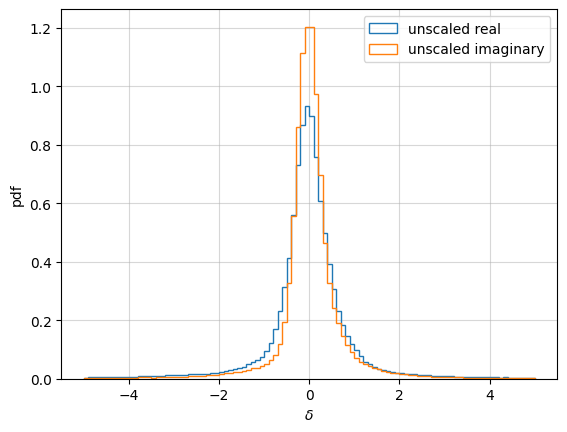

In [75]:
plt.hist(df_h2[abs(df_h2.delta_y5) < 5].delta_y5, bins=100, histtype='step', label='unscaled real', density=True)
plt.hist(df_h2[abs(df_h2.delta_y6) < 5].delta_y6, bins=100, histtype='step', label='unscaled imaginary', density=True)
plt.grid('dotted', alpha=0.5)
plt.xlabel(r'$\delta$')
plt.ylabel(r'pdf')
plt.legend()
plt.show()

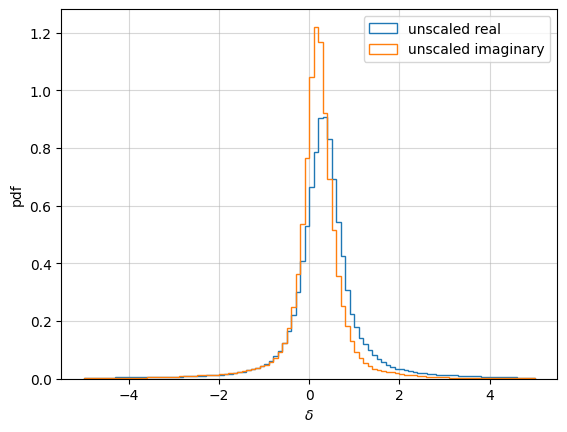

In [27]:
plt.hist(df_h2[abs(df_h2.delta_y5) < 5].delta_y5, bins=100, histtype='step', label='unscaled real', density=True)
plt.hist(df_h2[abs(df_h2.delta_y6) < 5].delta_y6, bins=100, histtype='step', label='unscaled imaginary', density=True)
plt.grid('dotted', alpha=0.5)
plt.xlabel(r'$\delta$')
plt.ylabel(r'pdf')
plt.legend()
plt.show()

In [36]:
df_h2[abs(df_h2.scaled_delta_y17) < 5].scaled_delta_y17

0        -0.04440178269978333619
1         0.01388438154246551121
2         0.09967005896512916296
3         0.05348801679989620417
4         0.02122195054123778707
                   ...          
499707   -0.37843966718479149502
499708   -0.10128042020253724687
499709   -0.71609470770447269938
499710    0.06232087426649454004
499711   -0.02978108146468904857
Name: scaled_delta_y17, Length: 490654, dtype: float64

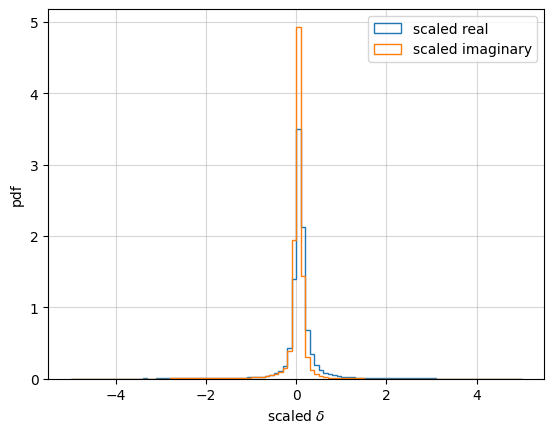

In [28]:
plt.hist(df_h2[abs(df_h2.scaled_delta_y5) < 5].scaled_delta_y5, bins=100, histtype='step', label='scaled real', density=True)
plt.hist(df_h2[abs(df_h2.scaled_delta_y6) < 5].scaled_delta_y6, bins=100, histtype='step', label='scaled imaginary', density=True)
plt.grid('dotted', alpha=0.5)
plt.xlabel(r'scaled $\delta$')
plt.ylabel(r'pdf')
plt.legend()
plt.show()

In [29]:
df_h2

,x1,x2,x3,x4,y5_scaled,y6_scaled,y5,y6,y5_scaled_pred,y6_scaled_pred,y5_pred,y6_pred,scaled_delta_y5,scaled_delta_y6,delta_y5,delta_y6
0,0.001656,0.771066,0.436337,0.521262,5.032712,-5.070183,152.348295,-158.203404,5.037163,-5.077358,153.032397,-159.349856,0.088445,0.141521,0.449038,0.724670
1,0.002124,0.581542,0.511984,0.521890,5.164520,-5.203726,173.953388,-180.948847,5.163800,-5.204524,173.827608,-181.094216,-0.013926,0.015347,-0.072307,0.080337
2,0.002743,0.463915,0.528051,0.508386,4.962266,-5.001355,141.917239,-147.614354,4.960350,-4.998779,141.643742,-147.232091,-0.038601,-0.051496,-0.192716,-0.258960
3,0.003052,0.961049,0.543344,0.505631,3.579522,-3.607909,34.856411,-35.888819,3.580510,-3.612176,34.891835,-36.046573,0.027586,0.118277,0.101628,0.439562
4,0.003572,0.361104,0.520037,0.524839,4.504727,-4.542012,89.443672,-92.879537,4.505312,-4.547334,89.496578,-93.380452,0.012982,0.117162,0.059151,0.539316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499707,0.502007,0.167341,0.524737,0.520739,-4.328688,-4.410747,-74.844741,-81.330981,-4.324564,-4.405729,-74.532576,-80.918821,-0.095279,-0.113784,-0.417084,-0.506769
499708,0.502228,0.420521,0.513963,0.519415,-3.474266,-3.918505,-31.274130,-49.325172,-3.474761,-3.921061,-31.290113,-49.453942,0.014250,0.065216,0.051105,0.261062
499709,0.502403,0.555022,0.528000,0.677927,-3.237579,-4.065832,-24.471969,-57.313389,-3.239206,-4.067871,-24.513451,-57.432402,0.050259,0.050146,0.169505,0.207653
499710,0.502513,0.233200,0.525068,0.503832,-4.021274,-4.145710,-54.772100,-62.162472,-4.023046,-4.141329,-54.871030,-61.886361,0.044072,-0.105676,0.180621,-0.444176
